# **03. Acquisition cohorts + customer engagement/spending**

## **Project Structure**

1. Cohort Definition
2. Customer Acquisition by Cohort
3. Spending by Cohort
4. Purchase Channels by Cohort
5. Campaign Response by Cohort
6. Web Engagement by Cohort
7. Recency by Cohort
8. Cohort Performance Heatmap
9. Cohort Summary
10. Key Findings
11. Business Recommendations


### **Introduction**

We will do **retention cohort and customer engagement analysis** using pre existed clean data namely, processed_data.csv file.

**NOTE :**
Cohort analysis should answer **customer retention/engagement questions**, but there is an important limitation: this dataset has __one row per customer__, not a full transaction history.


What cohort analysis can ask here
Using Dt_Customer as the customer's registration/joining date, you can investigate:

Which customer acquisition cohorts have the highest spending?

Example: Do customers who joined in 2012 spend more on average than those who joined in 2013?
How does customer behavior vary by acquisition month/year?

Compare MntWines, MntMeatProducts, MntGoldProds, etc. across cohorts.
Do newer cohorts show different purchasing behavior from older cohorts?

Which cohorts are more responsive to marketing campaigns?

Compare Response, AcceptedCmp1–AcceptedCmp5 across cohorts.
Which acquisition cohorts have higher web/store/catalog engagement?

Compare NumWebPurchases, NumStorePurchases, and NumCatalogPurchases.
Do customer characteristics differ across acquisition cohorts?

Income, household composition, education, children, etc.


**1. Import libraries and load data**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path


In [2]:

from IPython.display import display
from IPython.display import Markdown
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))


In [3]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)


0   cltv_df.csv
1   customer_segmentation.csv
2   customer_segmentation_cltv.csv
3   kmeans_df.csv
4   ParetoNBD_GammaGamma_CLTV_Analysis.csv
5   processed_cltv_segmentation.csv
6   processed_data.csv


In [63]:
display_md("**Loading Raw Dataset...**")
try:
    processed_df = pd.read_csv(data_path.joinpath('processed_data.csv'))
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    #customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%Y-%m-%d'), dayfirst=True)
    display_md(f"**Dataset Shape : {df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")



**Loading Raw Dataset...**

**Dataset Shape : (2214, 39)**

**Number of duplicate rows in dataset : 0**

### **2. Basic data inspection**

In [64]:
#missing vlaue check
df.stb.missing().query('percent > 0')

,missing,total,percent


In [65]:
df.head(2)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9


In [66]:
pd.read_csv(parent_path.joinpath('data', 'raw', 'marketing_campaign.csv'), sep='\t').head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


### **3. Clean Dt_Customer**

The Dt_Customer column contains the customer's registration date.



In [67]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%Y-%m-%d"
    #dayfirst=True
    #errors="coerce"
)

print(f"Dt_Customer Dtype : {df['Dt_Customer'].dtype}")
print(df["Dt_Customer"].min())
print(df["Dt_Customer"].max(), end="\n\n")

print("Missing dates:", df["Dt_Customer"].isna().sum())



Dt_Customer Dtype : datetime64[ns]
2012-07-30 00:00:00
2014-06-29 00:00:00

Missing dates: 0


In [72]:
df['Dt_Customer'].dt.strftime("%d-%m-%Y").apply(pd.to_datetime(format='%d-%m-%Y',dayfirst=True))

TypeError: to_datetime() missing 1 required positional argument: 'arg'

### **4. Create acquisition cohort**

We'll use the customer registration month as the cohort.

**A cohort = customers who joined/acquired the business during the same period.**



In [73]:
df["Cohort_Month"] = df["Dt_Customer"].dt.to_period("M")

# Check the cohorts
display(df["Cohort_Month"].value_counts().sort_index())



Cohort_Month
2012-07      2
2012-08    117
2012-09     97
2012-10     95
2012-11     96
2012-12     83
2013-01    107
2013-02     99
2013-03    101
2013-04     87
2013-05    102
2013-06     87
2013-07     98
2013-08    102
2013-09     94
2013-10    115
2013-11     87
2013-12     92
2014-01     88
2014-02     78
2014-03    108
2014-04     94
2014-05    111
2014-06     74
Freq: M, Name: count, dtype: int64

In [77]:
# Number of customers acquired in each cohort:

cohort_size = (
    df.groupby("Cohort_Month")
      .size()
      .reset_index(name="Customers")
)

display(cohort_size.head())


,Cohort_Month,Customers
0,2012-07,2
1,2012-08,117
2,2012-09,97
3,2012-10,95
4,2012-11,96


In [79]:
cohort_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype    
---  ------        --------------  -----    
 0   Cohort_Month  24 non-null     period[M]
 1   Customers     24 non-null     int64    
dtypes: int64(1), period[M](1)
memory usage: 516.0 bytes


### **5. Cohort customer acquisition trend**

This analysis answered Which months had the highest number of newly registered customers?



In [88]:
df['Cohort_Month'].dt.to_timestamp()

0      2012-09-01
1      2014-03-01
2      2013-08-01
3      2014-02-01
4      2014-01-01
5      2013-09-01
6      2012-11-01
7      2013-05-01
8      2013-06-01
9      2014-03-01
10     2012-11-01
11     2013-11-01
12     2013-11-01
13     2012-10-01
14     2012-11-01
15     2012-12-01
16     2012-08-01
17     2013-03-01
18     2012-11-01
19     2012-08-01
20     2013-01-01
21     2012-12-01
22     2014-01-01
23     2013-03-01
24     2013-01-01
25     2013-05-01
26     2013-05-01
27     2013-11-01
28     2014-05-01
29     2013-05-01
30     2012-10-01
31     2012-10-01
32     2013-02-01
33     2013-08-01
34     2013-12-01
35     2013-09-01
36     2014-02-01
37     2013-02-01
38     2013-04-01
39     2013-03-01
40     2012-12-01
41     2013-10-01
42     2014-06-01
43     2012-11-01
44     2013-05-01
45     2012-11-01
46     2014-05-01
47     2012-08-01
48     2013-01-01
49     2014-06-01
50     2013-06-01
51     2012-11-01
52     2013-04-01
53     2014-04-01
54     2014-03-01
55     201

plt.figure(figsize=(15, 5))

sns.lineplot(
    x=df['Cohort_Month'].dt.to_timestamp(),
    y='Customers',
    daa=cohort_size,
    marker='*'
)

plt.title("Customer Acquisition by Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Customer Registration Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **6. Create cohort year**

Sometimes monthly cohorts are too granular for this dataset.


Cohort_Year
2012     490
2013    1171
2014     553
Name: count, dtype: int64

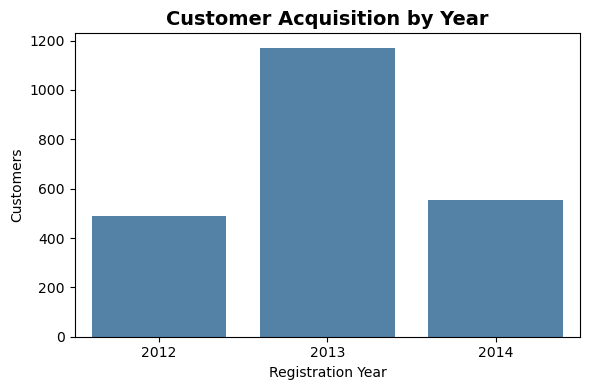

In [86]:

df["Cohort_Year"] = df["Dt_Customer"].dt.year

# Check:

display(df["Cohort_Year"].value_counts().sort_index())

# visualize
yearly_cohort = (
    df.groupby("Cohort_Year")
      .size()
      .reset_index(name="Customers")
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=yearly_cohort,
    x="Cohort_Year",
    y="Customers",
    color="steelblue"
)

plt.title("Customer Acquisition by Year", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Registration Year")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()



### **7. Cohort spending analysis**

Now we answer:

Do customers from different acquisition cohorts have different spending behavior?



,Cohort_Year,count,mean,median,sum
0,2012,490,746.597959,578.5,365833
1,2013,1171,603.064048,401.0,706188
2,2014,553,493.831826,165.0,273089


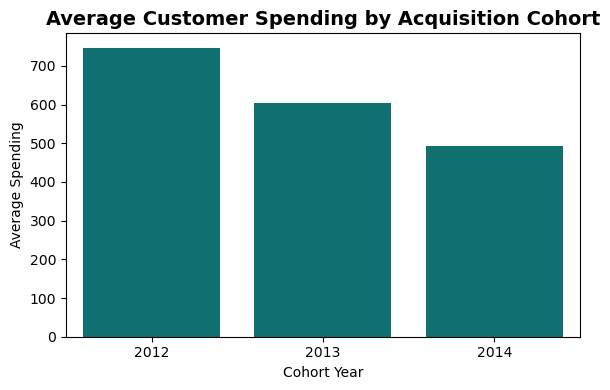

In [92]:
# Average spending by cohort year
cohort_spending = (
    df.groupby("Cohort_Year")["Monetary"]
      .agg(["count", "mean", "median", "sum"])
      .reset_index()
)

display(cohort_spending)

# visualization
plt.figure(figsize=(6, 4))

sns.barplot(
    data=cohort_spending,
    x="Cohort_Year",
    y="mean",
    color="teal"
)

plt.title("Average Customer Spending by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Average Spending")

plt.tight_layout()
plt.show()


### **8. Total spending contribution by cohort**

Which acquisition cohorts contribute the most total customer spending?

Be careful here: a cohort with more customers will naturally tend to have higher total spending. That's why __average spending per customer__ is often more useful.



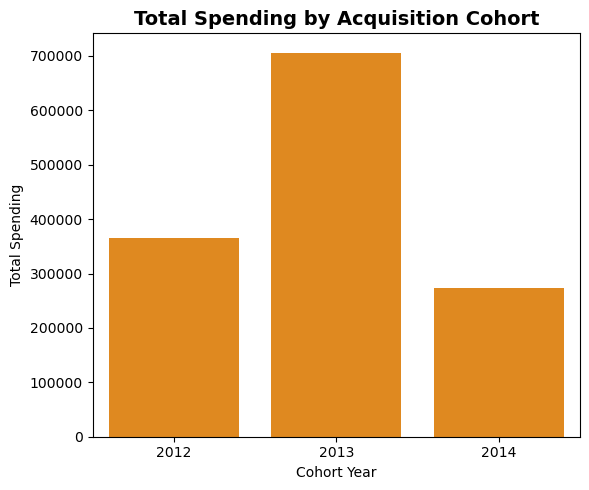

In [93]:
plt.figure(figsize=(6, 5))

sns.barplot(
    data=cohort_spending,
    x="Cohort_Year",
    y="sum",
    color="darkorange"
)

plt.title("Total Spending by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()


### **9. Analyze purchasing channels by cohort**

Question answered Do different acquisition cohorts prefer different purchasing channels?



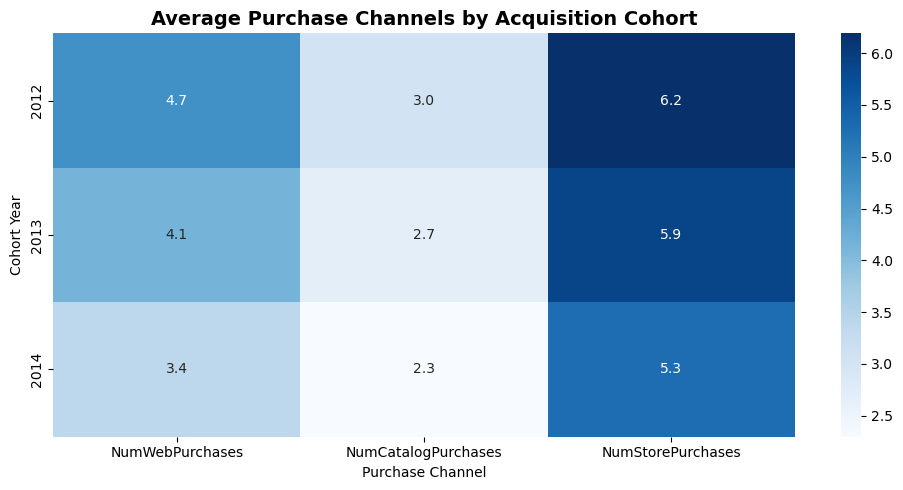

In [94]:
channel_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_by_cohort = (
    df.groupby("Cohort_Year")[channel_columns]
      .mean()
)

channel_by_cohort

# Heatmap plot
plt.figure(figsize=(10, 5))

sns.heatmap(
    channel_by_cohort,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Average Purchase Channels by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Purchase Channel")
plt.ylabel("Cohort Year")

plt.tight_layout()
plt.show()


### **10. Campaign response by cohort**

The Response variable represents response to the most recent campaign.

Question answered Which customer acquisition cohorts are more responsive to marketing campaigns?



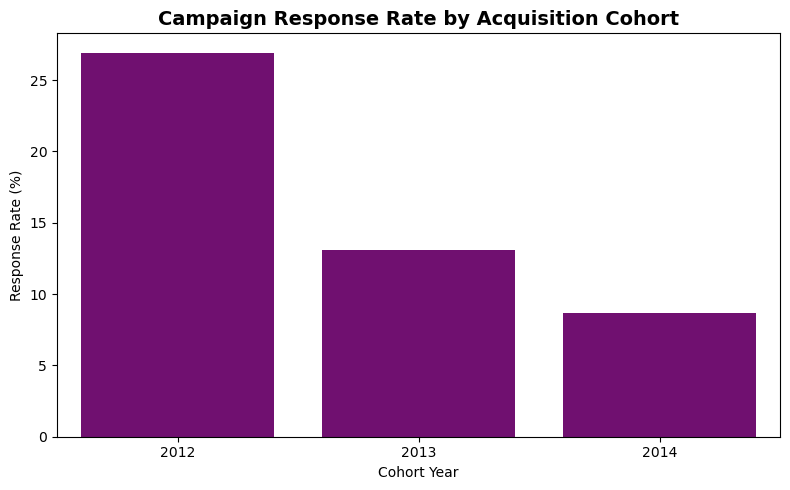

In [96]:
# calculate response rate
campaign_response = (
    df.groupby("Cohort_Year")["Response"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

campaign_response["Response_Rate"] = (
    campaign_response["mean"] * 100
)

campaign_response

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=campaign_response,
    x="Cohort_Year",
    y="Response_Rate",
    color="purple"
)

plt.title("Campaign Response Rate by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Response Rate (%)")

plt.tight_layout()
plt.show()


### **11. Campaign acceptance by cohort**

You can also examine the previous campaigns.



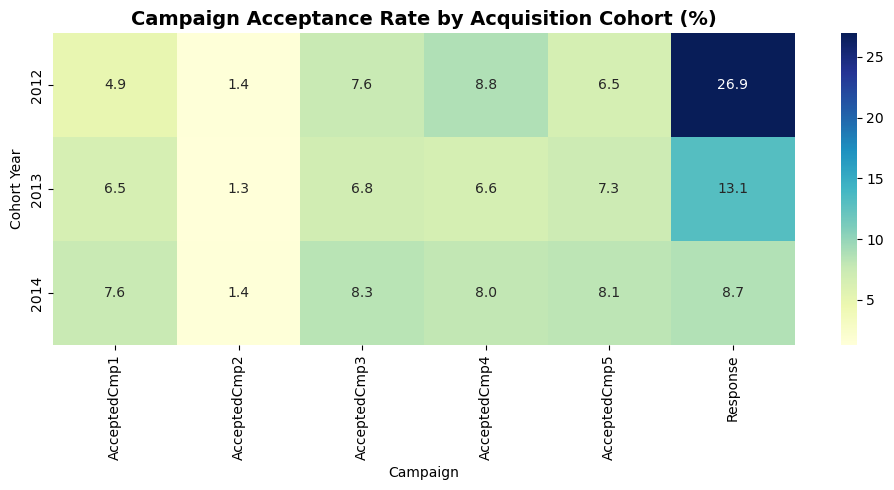

In [98]:
campaign_columns = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

# compute average percentage acceptance
campaign_by_cohort = (
    df.groupby("Cohort_Year")[campaign_columns]
      .mean() * 100
)

campaign_by_cohort.round(2)

# Heatmap Plot
plt.figure(figsize=(10, 5))

sns.heatmap(
    campaign_by_cohort,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Campaign Acceptance Rate by Acquisition Cohort (%)", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Campaign")
plt.ylabel("Cohort Year")

plt.tight_layout()
plt.show()


### **12. Web engagement by cohort**

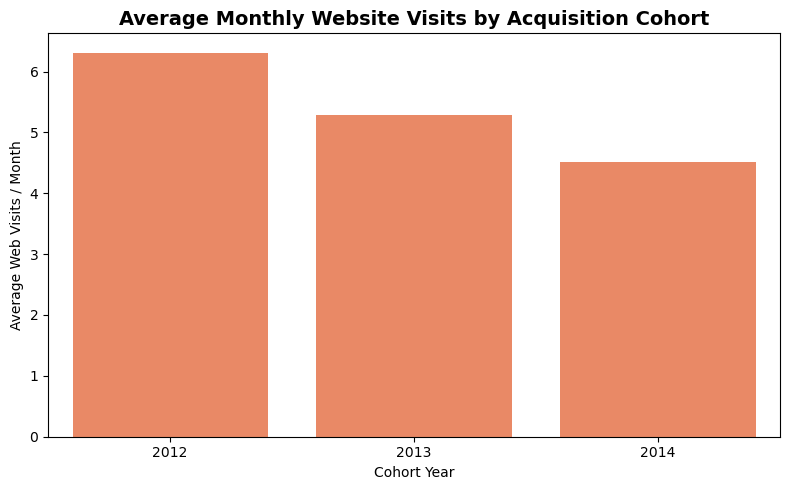

In [100]:
# the dataset has `NumWebVisitsMonth`
web_engagement = (
    df.groupby("Cohort_Year")["NumWebVisitsMonth"]
      .agg(["mean", "median"])
      .reset_index()
)

web_engagement

plt.figure(figsize=(8, 5))

sns.barplot(
    data=web_engagement,
    x="Cohort_Year",
    y="mean",
    color="coral"
)

plt.title("Average Monthly Website Visits by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Average Web Visits / Month")

plt.tight_layout()
plt.show()


### **13. Recency by cohort**

Recency is particularly useful.

It represents the number of days since the customer's last purchase.

**Lower recency = more recent purchase activity.**

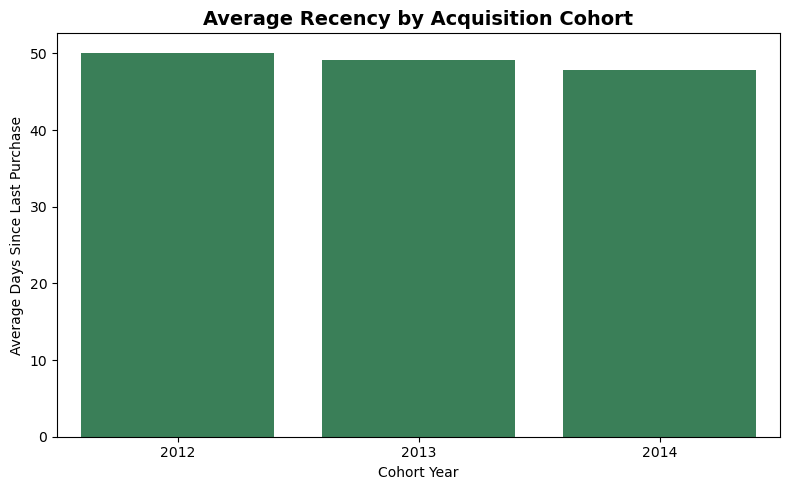

In [101]:
recency_by_cohort = (
    df.groupby("Cohort_Year")["Recency"]
      .agg(["mean", "median"])
      .reset_index()
)

recency_by_cohort

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=recency_by_cohort,
    x="Cohort_Year",
    y="mean",
    color="seagreen"
)

plt.title("Average Recency by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Average Days Since Last Purchase")

plt.tight_layout()
plt.show()


### **14. Create a cohort summary table**

In [103]:
cohort_summary = (
    df.groupby("Cohort_Year")
      .agg(
          Customers=("ID", "count"),
          Avg_Spending=("Monetary", "mean"),
          Median_Spending=("Monetary", "median"),
          Avg_Recency=("Recency", "mean"),
          Avg_Web_Purchases=("NumWebPurchases", "mean"),
          Avg_Catalog_Purchases=("NumCatalogPurchases", "mean"),
          Avg_Store_Purchases=("NumStorePurchases", "mean"),
          Campaign_Response_Rate=("Response", "mean")
      )
      .reset_index()
)

cohort_summary["Campaign_Response_Rate"] *= 100

display(cohort_summary.round(2))


,Cohort_Year,Customers,Avg_Spending,Median_Spending,Avg_Recency,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Campaign_Response_Rate
0,2012,490,746.60,578.5,50.11,4.74,3.03,6.19,26.94
1,2013,1171,603.06,401.0,49.15,4.14,2.70,5.89,13.07
2,2014,553,493.83,165.0,47.83,3.39,2.30,5.28,8.68


### **15. Normalize cohort performance**

To compare cohorts more easily:


In [104]:
metrics = [
    "Avg_Spending",
    "Avg_Recency",
    "Avg_Web_Purchases",
    "Avg_Catalog_Purchases",
    "Avg_Store_Purchases",
    "Campaign_Response_Rate"
]

display(cohort_summary[metrics].round(2))


,Avg_Spending,Avg_Recency,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Campaign_Response_Rate
0,746.60,50.11,4.74,3.03,6.19,26.94
1,603.06,49.15,4.14,2.70,5.89,13.07
2,493.83,47.83,3.39,2.30,5.28,8.68


### **16. Cohort spending distribution**

Instead of only comparing averages, look at distributions.

This is better than relying only on averages because customer spending is likely __to be skewed__.



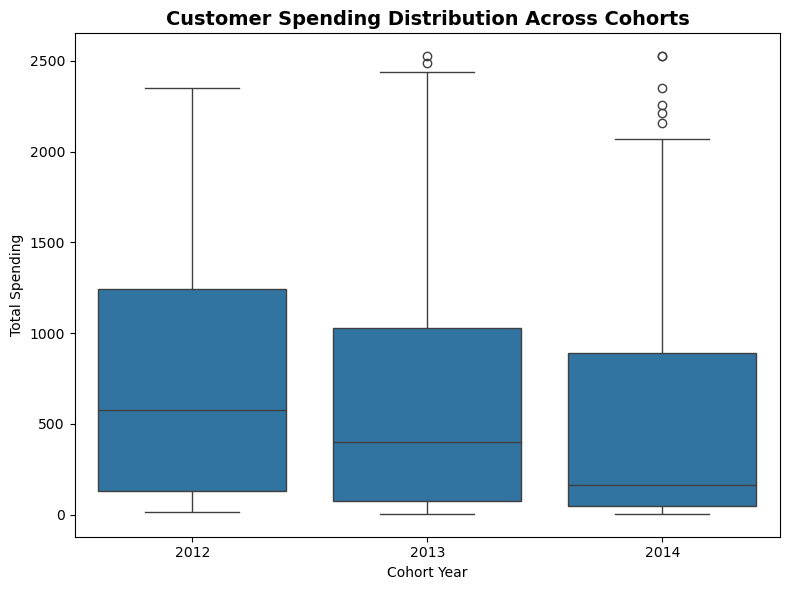

In [106]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Cohort_Year",
    y="Monetary"
)

plt.title("Customer Spending Distribution Across Cohorts", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()


### **17. Cohort vs customer behaviour**

You can also examine whether cohort is associated with customer personality variables.

For example, income:



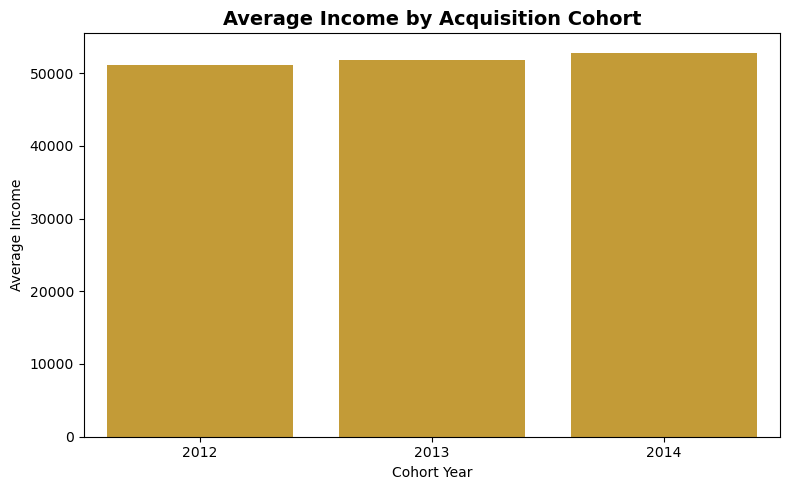

In [107]:
income_by_cohort = (
    df.groupby("Cohort_Year")["Income"]
      .mean()
      .reset_index()
)

income_by_cohort

# Plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=income_by_cohort,
    x="Cohort_Year",
    y="Income",
    color="goldenrod"
)

plt.title("Average Income by Acquisition Cohort", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Cohort Year")
plt.ylabel("Average Income")

plt.tight_layout()
plt.show()


### **18. Most important visualization: cohort performance heatmap**

Create a standardized score for selected metrics.

This gives you a nice portfolio visualization showing which cohorts are relatively stronger or weaker.




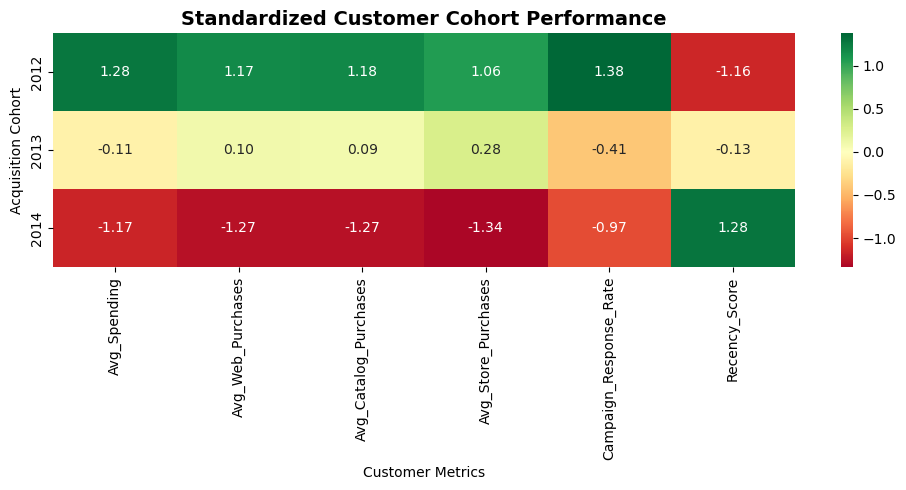

In [109]:
from sklearn.preprocessing import StandardScaler

cohort_metrics = cohort_summary[
    [
        "Cohort_Year",
        "Avg_Spending",
        "Avg_Recency",
        "Avg_Web_Purchases",
        "Avg_Catalog_Purchases",
        "Avg_Store_Purchases",
        "Campaign_Response_Rate"
    ]
].set_index("Cohort_Year")

# Because lower Recency is better, reverse it before standardization:

cohort_metrics["Recency_Score"] = -cohort_metrics["Avg_Recency"]

cohort_metrics = cohort_metrics.drop(columns=["Avg_Recency"])

scaler = StandardScaler()

scaled_metrics = pd.DataFrame(
    scaler.fit_transform(cohort_metrics),
    index=cohort_metrics.index,
    columns=cohort_metrics.columns
)

scaled_metrics.round(2)

# Heatmap
plt.figure(figsize=(10, 5))

sns.heatmap(
    scaled_metrics,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("Standardized Customer Cohort Performance", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Customer Metrics")
plt.ylabel("Acquisition Cohort")

plt.tight_layout()
plt.show()


### **19. Create an overall cohort score**

In [110]:
cohort_score = scaled_metrics.copy()

cohort_score["Overall_Score"] = (
    cohort_score["Avg_Spending"] +
    cohort_score["Recency_Score"] +
    cohort_score["Avg_Web_Purchases"] +
    cohort_score["Avg_Catalog_Purchases"] +
    cohort_score["Avg_Store_Purchases"] +
    cohort_score["Campaign_Response_Rate"]
) / 6

cohort_score["Overall_Score"].sort_values(ascending=False)

# Top-performing cohort:

best_cohort = cohort_score["Overall_Score"].idxmax()

print("Best performing cohort:", best_cohort)

# Lowest-performing cohort:

worst_cohort = cohort_score["Overall_Score"].idxmin()

print("Lowest performing cohort:", worst_cohort)


Best performing cohort: 2012
Lowest performing cohort: 2014


"Because the dataset contains customer-level records rather than transaction-level purchase histories, cohort analysis is used to compare acquisition cohorts on spending, engagement, purchasing channels, recency, and campaign response rather than traditional month-over-month retention."



### **20. Key Findings**

### **21. Business Recommendations**